In [48]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import ttest_ind
import pandas as pd
import seaborn as sns
import os
import sys
import pickle

In [2]:
data_directory = '/mnt/Data/Behavioural_Data/Bpod_data/'
experiment_name = 'D-AP5-Chronic-Infusion-SP120-137_Aug23_Analysis'
data_path = os.path.join(data_directory, experiment_name)

In [3]:
# list all the .pkl files in the current directory

pkl_files = [file for file in os.listdir(data_path) if file.endswith('.pkl')]

print(pkl_files)

['D-AP5-Chronic-Infusion-SP120-137_Aug23_dataframe.pkl']


In [4]:
# list pickle files in the data_path and load them as dictionaries
data_file = os.path.join(data_path, pkl_files[0])
with open(data_file, 'rb') as f:
    data = pickle.load(f)
print(data.keys())

Index(['AnimalID', 'ExperimentalGroup', 'SessionTime', 'FullSessionTime',
       'Protocol', 'Stimulation', 'Muscimol', 'RewardChange',
       'RewardChangeBlock', 'CenterPortDuration', 'Contingency',
       'RewardAmount', 'PunishDelay', 'Punish', 'BiasCorrection', 'TrialIndex',
       'TrialHighPerc', 'Outcomes', 'OptoStim', 'FirstPokeCorrect',
       'FirstPoke', 'TrialSide', 'TrialSequence', 'ResponseTime',
       'TrialStartTimestamp', 'CumulativePerformance', 'SwitchSide',
       'PreviousChoice', 'TrialEvents', 'TrialStates', 'FullGUI', 'SessionID',
       'ITIs', 'CumulativeTrialNumber', 'CumulativeTrialNumberByProtocol',
       'CurrentPastPerformance20', 'CurrentPastPerformance100',
       'NoOfCenterPokes', 'MiddleWaitTime', 'TrialInitiationTime', 'RightBias',
       'TrialsSpeed', 'PrevTrialSuccess'],
      dtype='object')


In [5]:
# convert the dictionary to a dataframe
df = pd.DataFrame(data)
df.head()

,AnimalID,ExperimentalGroup,SessionTime,FullSessionTime,Protocol,Stimulation,Muscimol,RewardChange,RewardChangeBlock,CenterPortDuration,...,CumulativeTrialNumber,CumulativeTrialNumberByProtocol,CurrentPastPerformance20,CurrentPastPerformance100,NoOfCenterPokes,MiddleWaitTime,TrialInitiationTime,RightBias,TrialsSpeed,PrevTrialSuccess
0,SP120,D-AP5,May26 16:24,2023-05-26 16:24:00,Habituation,NoStimulation,No,No,0,0.03,...,1,1.0,NaN,NaN,1,0.036407,290.7158,NaN,NaN,NaN
14,SP120,D-AP5,May26 16:24,2023-05-26 16:24:00,Habituation,NoStimulation,No,No,0,0.03,...,2,2.0,NaN,NaN,1,0.210900,NaN,NaN,NaN,0.0
17,SP120,D-AP5,May26 16:24,2023-05-26 16:24:00,Habituation,NoStimulation,No,No,0,0.03,...,3,3.0,NaN,NaN,1,0.349400,38.5954,NaN,1.313154,1.0
27,SP120,D-AP5,May26 16:24,2023-05-26 16:24:00,Habituation,NoStimulation,No,No,0,0.03,...,4,4.0,NaN,NaN,1,0.063000,49.1914,NaN,1.756277,1.0
34,SP120,D-AP5,May26 16:24,2023-05-26 16:24:00,Habituation,NoStimulation,No,No,0,0.03,...,5,5.0,NaN,NaN,1,0.058800,8.2032,NaN,1.751116,1.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 104384 entries, 0 to 113749
Data columns (total 43 columns):
AnimalID                           104384 non-null object
ExperimentalGroup                  104384 non-null object
SessionTime                        104384 non-null object
FullSessionTime                    104384 non-null datetime64[ns]
Protocol                           104384 non-null object
Stimulation                        104384 non-null object
Muscimol                           104384 non-null object
RewardChange                       104384 non-null object
RewardChangeBlock                  104384 non-null int64
CenterPortDuration                 104384 non-null float64
Contingency                        104384 non-null int64
RewardAmount                       104384 non-null int64
PunishDelay                        104384 non-null int64
Punish                             104384 non-null object
BiasCorrection                     104384 non-null int64
TrialIndex     

### First saline session after chronic D-AP5 treatment: Task performance (%)

In [ ]:
dates = df['FullSessionTime'].unique()
# print(dates)

In [31]:
# Provide AnimalIDs and dates for analysis
# refer to https://docs.google.com/spreadsheets/d/1ySelwJm3NSk8DC0BfwePGAgFHRN1nxvFOZ7CzhhhI9k/edit?usp=sharing
# D-AP5 and slaine dates according to animalIDs
# Note: For the D-AP5 group it needs to be manually checked as not all mice were stopped D-AP5 infusion once they reached 3000 trials

AP5_mice = ['SP120', 'SP121', 'SP122', 'SP124', 'SP126']
AP5_dates = ['2023-06-07', '2023-06-09', '2023-06-08', '2023-06-05', '2023-06-05']


# saline date for saline group is the session after they cross 3000 trials
# write a code block to loop through df and get the dates in the above format of the next session of the session in which the mouse crosses 3000 trials.

# Assuming df is already read into your environment
saline_df = df[df['ExperimentalGroup'] == 'Saline']

# Filter for 'Auditory' protocol
auditory_df = saline_df[saline_df['Protocol'] == 'Auditory']

# First, let's sort the dataframe by 'AnimalID' and 'FullSessionTime' to ensure it's in date order for each animal.
auditory_df = auditory_df.sort_values(by=['AnimalID', 'FullSessionTime'])

# Now, filter rows where 'CumulativeTrialNumberByProtocol' is greater than 3000
filtered_df = auditory_df[auditory_df['CumulativeTrialNumberByProtocol'] > 3000]

# For each 'AnimalID', get the first occurrence (i.e., the earliest date) where the condition is met
first_crossed_date = filtered_df.groupby('AnimalID').agg({'FullSessionTime': 'first'}).reset_index()

# Add an 'ExperimentalGroup' column with the value 'Saline'
first_crossed_date['ExperimentalGroup'] = 'Saline'

# Create a DataFrame from AP5_mice and AP5_dates
ap5_df = pd.DataFrame({
    'AnimalID': AP5_mice,
    'FullSessionTime': AP5_dates,
    'ExperimentalGroup': 'D-AP5'
})

# Merge this data with first_crossed_date
# First, let's append the AP5 data to first_crossed_date
combined_df_saline_after_3000 = pd.concat([first_crossed_date, ap5_df], ignore_index=True)

# Now, since some mice might appear twice in combined_df_saline_after_3000 (once for crossing 3000, once for AP5 injection),
# we want to make sure to keep the earliest date for each mouse
combined_df_saline_after_3000 = combined_df_saline_after_3000.sort_values(by=['AnimalID', 'FullSessionTime'])
combined_df_saline_after_3000 = combined_df_saline_after_3000.groupby('AnimalID').first().reset_index()

# Convert the 'FullSessionTime' column to datetime and format it to only keep yyyy-mm-dd
combined_df_saline_after_3000['FullSessionTime'] = pd.to_datetime(combined_df_saline_after_3000['FullSessionTime']).dt.strftime('%Y-%m-%d')

print(combined_df_saline_after_3000)


   AnimalID FullSessionTime ExperimentalGroup
0     SP120      2023-06-07             D-AP5
1     SP121      2023-06-09             D-AP5
2     SP122      2023-06-08             D-AP5
3     SP124      2023-06-05             D-AP5
4     SP126      2023-06-05             D-AP5
5     SP132      2023-08-16            Saline
6     SP133      2023-08-14            Saline
7     SP134      2023-08-15            Saline
8     SP135      2023-08-15            Saline
9     SP136      2023-08-16            Saline
10    SP137      2023-08-15            Saline


In [111]:
def perf_window_calculator(firstpokecorrect, window):
    """
    Calculate the performance of the last X trials
    This is a function written by Hernando and used in APE paper (Greenstreet et al., 2022 for analysis)
    """
    perf_window = np.full(len(firstpokecorrect), np.nan)
    for i in range(len(perf_window)):
        if i < window:
            # For the first window-1 trials, dynamically adjust the window size
            current_window_size = i + 1
            perf_window[i] = np.nansum(firstpokecorrect[:i+1]) / current_window_size * 100
        else:
            perf_window[i] = np.nansum(firstpokecorrect[i - window + 1: i + 1]) / window * 100
    return perf_window

In [120]:
def plot_performance_by_group(df, group_colors, alpha=1, exclude_animal_ids=[], window=100):
    """
    Plot performance by experimental group.
    
    Parameters:
    - df: DataFrame with data.
    - group_colors: Dictionary specifying colors for each group.
    - alpha: Transparency for the swarmplot.
    - exclude_animal_ids: List of animal IDs to exclude.
    """
    
    df = df.copy()
    # Calculate the performance based on window size
    df['CumulativePerformance'] = perf_window_calculator(df['FirstPokeCorrect'], window)

    # Filter out rows with animal IDs to exclude
    if exclude_animal_ids:
        df = df[~df['AnimalID'].isin(exclude_animal_ids)]
   
    # Convert the 'FullSessionTime' column of df to string format
    df['FullSessionTime'] = pd.to_datetime(df['FullSessionTime']).dt.strftime('%Y-%m-%d')

    # Merge to get the required sessions
    selected_data = df.merge(combined_df_saline_after_3000[['AnimalID', 'FullSessionTime', 'ExperimentalGroup']], 
                             on=['AnimalID', 'FullSessionTime'], 
                             how='inner')

    selected_data.drop('ExperimentalGroup_x', axis=1, inplace=True)
    selected_data.rename(columns={'ExperimentalGroup_y': 'ExperimentalGroup'}, inplace=True)

    # Extract data for t-test
    d_ap5_performance = selected_data[selected_data['ExperimentalGroup'] == 'D-AP5']['CumulativePerformance']
    saline_performance = selected_data[selected_data['ExperimentalGroup'] == 'Saline']['CumulativePerformance']

    # Remove NaN values
    saline_performance = saline_performance.dropna()
    d_ap5_performance = d_ap5_performance.dropna()

    # Perform t-test
    t_stat, p_value = ttest_ind(d_ap5_performance, saline_performance, equal_var=False, nan_policy='omit')
    print('t-statistic:', t_stat)
    print('p-value:', p_value)

    # Plotting
    plt.figure(figsize=(6, 8))

    # Boxplot
    sns.boxplot(data=selected_data, x='ExperimentalGroup', y='CumulativePerformance', palette=group_colors, order=['Saline', 'D-AP5'], width=0.2)   

    # Adjust x-coordinates for swarmplot to plot beside the boxplot
    offset = 0.2  
    swarm_adjust = lambda x: -offset if x == "Saline" else 1 + offset
    selected_data['SwarmX'] = selected_data['ExperimentalGroup'].apply(swarm_adjust)

    # Swarmplot
    sns.swarmplot(data=selected_data, x='SwarmX', y='CumulativePerformance', hue='ExperimentalGroup', palette=group_colors, dodge=True, size=3, alpha=alpha)

    # Hide the SwarmX axis and set the x-axis ticks and labels
    ax = plt.gca()
    ax.axes.get_xaxis().set_visible(False)
    ax.set_xticks([-offset, 1+offset])
    ax.set_xticklabels(['Saline', 'D-AP5'])

    # Adjust legend
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles, labels=labels, loc='upper right')

    # Title, labels, and p-value
    plt.title(f"First saline session after chronic D-AP5 infusion\np-value = {p_value:.4f}")
    plt.ylabel('Task Performance (%)')
    plt.xlabel('Experimental Group')
    plt.ylim(50, max(selected_data['CumulativePerformance']) + 5)
    plt.tight_layout()
    plt.show()


t-statistic: -53.90420823941589
p-value: 0.0


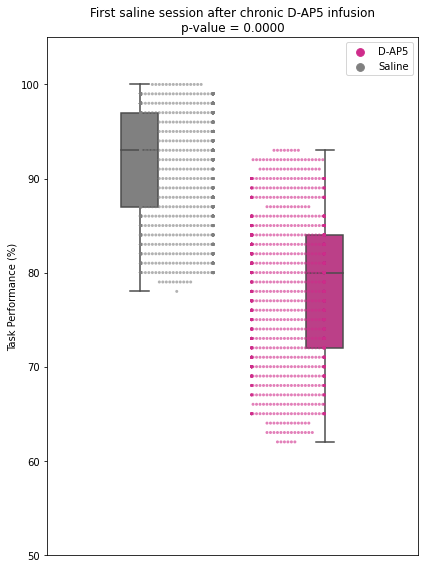

In [121]:

group_colors = {'Saline': '#808080', 'D-AP5': '#cf2c8b'}
plot_performance_by_group(df, group_colors, alpha=0.6, exclude_animal_ids=['SP124'], window=100)


### Here plot cumulative performance comparision between saline, D-AP5 and olanzapine infusion in expert mice performing COT task

In [122]:
animals = ['SP'+str(i) for i in range(120, 126) if i != 123]

saline_dates = ['2023-07-21', '2023-07-25', '2023-07-31', '2023-08-01']
dap5_dates = ['2023-07-24', '2023-07-26']
olanzapine_dates = ['2023-08-03']

In [125]:
def plot_performance_expert_mice(df, group_colors, alpha=1, exclude_animal_ids=[], window=100):
    """
    Plot performance by experimental group for expert mice.
    
    Parameters:
    - df: DataFrame with data.
    - group_colors: Dictionary specifying colors for each group.
    - alpha: Transparency for the swarmplot.
    """
    
    # Filter for animals
    df = df[df['AnimalID'].isin(animals)]  # Create a copy to avoid warnings

    df = df.copy()
    # Calculate the performance based on window size
    df['CumulativePerformance'] = perf_window_calculator(df['FirstPokeCorrect'], window)

    # Filter out rows with animal IDs to exclude
    if exclude_animal_ids:
        df = df[~df['AnimalID'].isin(exclude_animal_ids)]
    
    # Assign ExperimentalGroup based on dates
    conditions = [
        df['FullSessionTime'].isin(saline_dates),
        df['FullSessionTime'].isin(dap5_dates),
        df['FullSessionTime'].isin(olanzapine_dates)
    ]
    choices = ['Saline', 'D-AP5', 'Olanzapine']
    df['ExperimentalGroup'] = np.select(conditions, choices, default=np.nan)
    
    # Filter out any rows where ExperimentalGroup is 'nan' string or NaN
    df = df[df['ExperimentalGroup'].notna() & (df['ExperimentalGroup'] != 'nan')]
    
    # Debug step: Print unique values after filtering
    # print("ExperimentalGroup values:", df['ExperimentalGroup'].unique())
    
    # Extract data for t-tests
    saline_performance = df[df['ExperimentalGroup'] == 'Saline']['CumulativePerformance']
    d_ap5_performance = df[df['ExperimentalGroup'] == 'D-AP5']['CumulativePerformance']
    olanzapine_performance = df[df['ExperimentalGroup'] == 'Olanzapine']['CumulativePerformance']

    # Remove NaN values
    saline_performance = saline_performance.dropna()
    d_ap5_performance = d_ap5_performance.dropna()
    olanzapine_performance = olanzapine_performance.dropna()

    # Perform t-tests
    t_stat_dap5_saline, p_value_dap5_saline = ttest_ind(d_ap5_performance, saline_performance, equal_var=False, nan_policy='omit')
    t_stat_olanzapine_saline, p_value_olanzapine_saline = ttest_ind(olanzapine_performance, saline_performance, equal_var=False, nan_policy='omit')
    print('D-AP5 vs Saline: t-statistic:', t_stat_dap5_saline, 'p-value:', p_value_dap5_saline)
    print('Olanzapine vs Saline: t-statistic:', t_stat_olanzapine_saline, 'p-value:', p_value_olanzapine_saline)
    
    # Plotting
    plt.figure(figsize=(6, 8))
    
    # Boxplot
    sns.boxplot(data=df, x='ExperimentalGroup', y='CumulativePerformance', palette=group_colors, order=['Saline', 'D-AP5', 'Olanzapine'], width=0.2)   

    # Adjust x-coordinates for swarmplot to plot beside the boxplot
    offset = 0.35
    swarm_adjust = lambda x: -offset if x == "Saline" else (0 if x == "D-AP5" else 1 + offset)
    df['SwarmX'] = df['ExperimentalGroup'].apply(swarm_adjust)
    # print("SwarmX values:", df['SwarmX'].unique())
    # Swarmplot
    sns.swarmplot(data=df, x='SwarmX', y='CumulativePerformance', hue='ExperimentalGroup', palette=group_colors, dodge=True, size=3, alpha=alpha)

    # Adjust axes and legend
    ax = plt.gca()
    ax.axes.get_xaxis().set_visible(False)
    ax.set_xticks([-offset, 0, 1+offset])
    ax.set_xticklabels(['Saline', 'D-AP5', 'Olanzapine'])
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles, labels=labels, loc='lower right')
    
    # Title, labels, and p-value
    plt.title(f"Task Performance in expert mice\nD-AP5 vs Saline p-value = {p_value_dap5_saline:.4f}\nOlanzapine vs Saline p-value = {p_value_olanzapine_saline:.4f}")
    plt.ylabel('Task Performance (%)')
    plt.xlabel('Experimental Group')
    plt.ylim(50, max(df['CumulativePerformance']) + 5)
    plt.tight_layout()
    plt.show()



D-AP5 vs Saline: t-statistic: 2.143651515149611 p-value: 0.032103262828022526
Olanzapine vs Saline: t-statistic: 9.511460839751784 p-value: 3.9179726973071275e-21


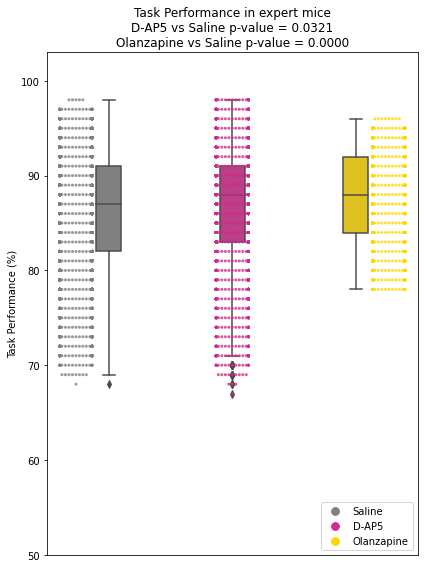

In [126]:
group_colors = {'Saline': '#808080', 'D-AP5': '#cf2c8b', 'Olanzapine': '#FFD700'}  
plot_performance_expert_mice(df, group_colors, alpha=0.8, exclude_animal_ids=['SP124'], window=100)